# **Univariable Non-Linear Regression Model**

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import random

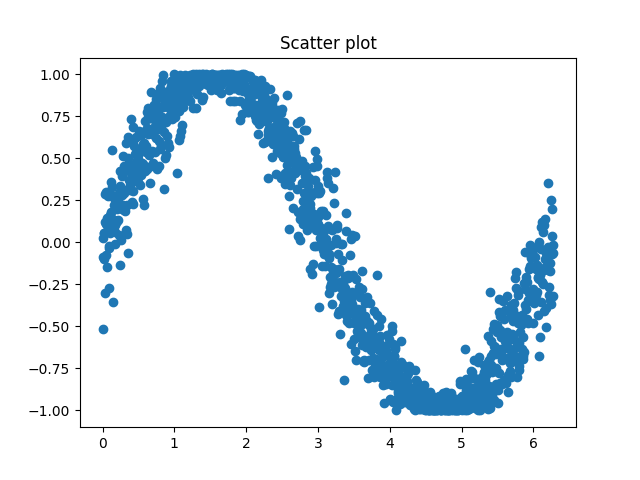

In [2]:
x = np.arange(0, 2*np.pi, 0.005)
y = np.array([np.sin(e + np.random.normal(0, 0.2)) for e in x])

# display(x.shape, y.shape)
# display(x, y)
fig = plt.figure()
plt.title("Scatter plot")
plt.scatter(x, y)

In [3]:
# NORMALIZE DATA for one feature
max_x = np.amax(x)      
min_x = np.amin(x)
    
x = np.array([(e - min_x)/(max_x - min_x) for e in x])

max_y = np.amax(y)
min_y = np.amin(y)
y = np.array([( e - min_y)/(max_y - min_y) for e in y])

# display(x.shape, y.shape)
# display(x, y)

In [4]:
# 70% for train and 30% test
m, = y.shape
idx = np.array(np.arange(m))
include_idx = set(np.random.choice(idx, size = int(0.7*m), replace=False))
mask = np.array([(i in include_idx) for i in range(m)])

trainX = x[mask]
testX = x[~mask]

trainY = y[mask]
testY = y[~mask]

# display(trainX.shape, testX.shape)
# display(trainY.shape, testY.shape)

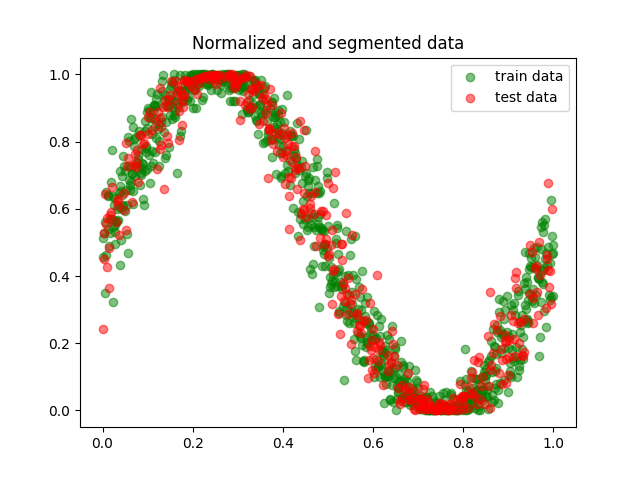

In [5]:
fig = plt.figure()
plt.title("Normalized and segmented data")
plt.scatter(trainX, trainY, color="green", alpha=0.5, label="train data")
plt.scatter(testX, testY, color="red", alpha=0.5, label="test data")
plt.legend()

In [6]:
def h(x, w):
  return np.sum(np.multiply(x, w))

In [7]:
def Error(y, x, w):
  m, = y.shape
  e = 0
  for j in range(m):
    sum = (float(y[j] - h(x[j,:], w))**2)/(2.0*m)
    e = e + sum
  return e

In [8]:
def derivada(x,y,params):
  #implementar las derivadas
  m, = y.shape
  r, c = x.shape

  # first derivative
  derivatives = np.array(
    [ sum([(y[i] - h(x[i,:],params))*-1 for i in range(m)])/(m*1.0) ]
  )
  
  for j in range(1, c):
    der = sum([(y[i] - h(x[i,:], params))*-x[i, j] for i in range(m)])/(m*1.0)
    derivatives = np.append(derivatives, der)
  
  return derivatives

In [9]:
def update(params, alfa, deriv):
  return params - alfa*deriv

In [10]:
arrL = []

def train(x, y, alfa, p, epochs):
  w = np.array([np.random.rand() for i in range(p+1)])     # k+1 parametros w0 + w1x1 + ... wkxk
  
  # display(x)
  # display(w)
  i = 0
  for _ in range(epochs):
    L = Error(y, x, w)     
    arrL.append(L)
    
    derivatives = derivada(x, y, w)
    w = update(w ,alfa, derivatives)     
    
    if _ % 50 == 0:
      print(f"L: {L} ", end="")
    if _ % 100 == 0:
      print()
    
    # time.sleep(2)
  return w

In [11]:
def test(x, y, w, p):
   print(f'Error: {Error(y, x, w)}')

   # 2D PLOT
   fig = plt.figure()
   plt.title("Error function along training")
   plt.ylabel("L")
   plt.xlabel("epochs")
   plt.plot(np.arange(1,len(arrL)+1), arrL)

   # 2D FUNCTION PLOT
   xAxis = np.linspace(0, 1, 100)
   yAxis = paramArr[0]
   title = str(round(paramArr[0],2))
   for i in range(1, p+1):
      yAxis += paramArr[i]*(xAxis**i)
      title += " + " + str(round(paramArr[i],2)) + f"*x^{i}"
   
   fig = plt.figure()
   plt.title("Univariable Non-Linear Regression")
   plt.scatter(trainX, trainY, color="green", alpha=0.5)
   plt.scatter(testX, testY, color="red", alpha=0.5)
   
   plt.plot(xAxis, yAxis, 'b', label=title)
   plt.legend(loc= 3, prop={'size': 5.5})

In [12]:
# EXTEND ARRAY
p = 6
epochs = 2500
alfa = 0.5

auxX = []
for feature in trainX:         # feature np.array int
    nRow = []
    for i in range(p+1):
        nRow.append(feature**i)
    auxX.append(nRow)
extendX = np.array(auxX)

In [13]:
arrL = []
paramArr = train(extendX, trainY, alfa , p, epochs)
paramArr

L: 0.577633144716974 
L: 0.025894628487665185 L: 0.021210038108833214 
L: 0.01922486964722538 L: 0.01817114099757577 
L: 0.017450676182908773 L: 0.01686049228327671 
L: 0.0163311512777454 L: 0.0158383705358233 
L: 0.015373161884772316 L: 0.014931742305472602 
L: 0.014512123775570504 L: 0.014112959486774452 
L: 0.013733152375679854 L: 0.013371721255488767 
L: 0.013027754047636852 L: 0.012700390512508902 
L: 0.012388815017397454 L: 0.012092252763762572 
L: 0.01180996724833052 L: 0.011541258203047465 
L: 0.011285459755800975 L: 0.011041938721830012 
L: 0.010810092992639884 L: 0.01058935000859354 
L: 0.010379165308018561 L: 0.01017902114804249 
L: 0.009988425193287983 L: 0.009806909268979888 
L: 0.009634028175263393 L: 0.00946935855971577 
L: 0.009312497845191794 L: 0.009163063210285222 
L: 0.009020690619824155 L: 0.008885033902944522 
L: 0.008755763876406775 L: 0.008632567510935612 
L: 0.008515147138470987 L: 0.0084032196983233 
L: 0.008296516020323021 L: 0.008194780143149553 
L: 0.008097

array([ 0.78551744,  0.9352153 , -2.22396317, -1.89861273,  0.01992882,
        1.0578653 ,  1.96025839])

Error: 0.007402575913703431


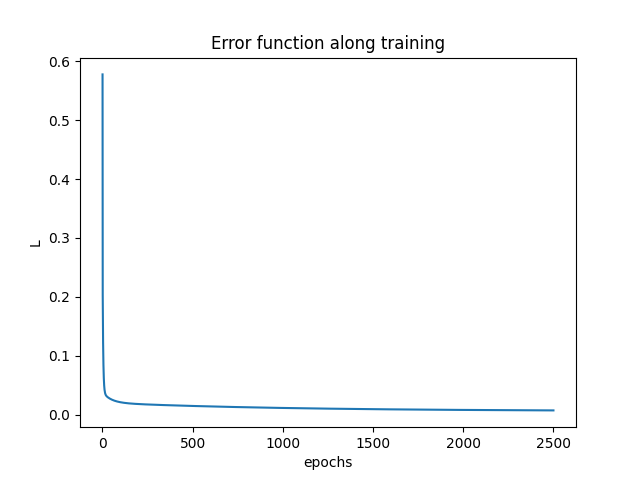

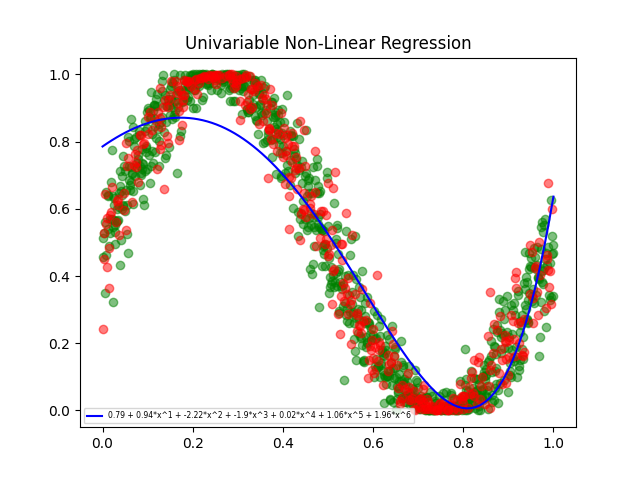

In [14]:
test(extendX, trainY, paramArr, p)